# XGBoost (eXtreme Gradient Boosting)

## What Is XGBoost?

XGBoost is an **optimized, regularized implementation of Gradient Boosting**. It follows the same sequential tree-building framework — each new tree corrects the errors of the previous ensemble — but adds several algorithmic improvements that make it faster, more accurate, and less prone to overfitting.

## Where It Sits in the ML Evolution

| Algorithm | Core Idea |
|---|---|
| Decision Tree | Single tree |
| Random Forest | Bagging — reduces variance |
| AdaBoost | Boosting — reduces bias |
| Gradient Boosting | Fits residuals using gradients |
| **XGBoost** | Regularized, optimized Gradient Boosting |

## The Objective Function

Standard Gradient Boosting minimizes only the training loss. XGBoost minimizes a **regularized objective** that penalizes model complexity directly:

$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{t=1}^{T} \Omega(f_t)$$

Where:

- $l(y_i, \hat{y}_i)$ is the **loss function** — log-loss for classification, MSE for regression
- $\Omega(f_t)$ is the **regularization term** for tree $t$

The regularization term penalizes both the number of leaves and the magnitude of leaf weights:

$$\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j} w_j^2$$

Where:

- $T$ is the number of leaves in the tree
- $w_j$ is the weight (output value) of leaf $j$
- $\gamma$ penalizes adding more leaves — discourages overly complex trees
- $\lambda$ is L2 regularization on the leaf weights — shrinks leaf values toward zero

This is the key difference from standard Gradient Boosting. By building regularization directly into the objective, XGBoost controls overfitting at the mathematical level rather than relying purely on hyperparameter constraints like `max_depth`.

## Second-Order Optimization

Standard Gradient Boosting uses only the **first derivative** (gradient) of the loss to guide tree fitting. XGBoost uses a **second-order Taylor expansion** of the loss, incorporating both the gradient and the Hessian:

$$\mathcal{L}^{(m)} \approx \sum_{i=1}^{n} \left[ l(y_i, \hat{y}_i^{(m-1)}) + g_i f_m(\mathbf{x}_i) + \frac{1}{2} h_i f_m(\mathbf{x}_i)^2 \right] + \Omega(f_m)$$

Where:

- $g_i = \dfrac{\partial \, l(y_i, \hat{y}_i)}{\partial \hat{y}_i}$ is the **gradient** (first derivative)
- $h_i = \dfrac{\partial^2 l(y_i, \hat{y}_i)}{\partial \hat{y}_i^2}$ is the **Hessian** (second derivative)

The Hessian captures the **curvature** of the loss surface. Using it allows XGBoost to take more precise steps — it knows not just which direction to move, but how large a step is safe. This leads to faster convergence and more stable training compared to first-order methods.

## Loss Functions

XGBoost uses the same framework for both tasks — only the loss function changes.

**Classification** — Binary Cross-Entropy:

$$\mathcal{L} = -\left[y\log(p) + (1-y)\log(1-p)\right]$$

**Regression** — Mean Squared Error:

$$\mathcal{L} = (y - \hat{y})^2$$

The gradients and Hessians are derived analytically from whichever loss is chosen, and the rest of the algorithm proceeds identically.

## Key Improvements Over Standard Gradient Boosting

**Regularization** — $\gamma$ and $\lambda$ are built into the objective, directly penalizing tree complexity and large leaf weights. Standard Gradient Boosting has no equivalent.

**Second-order optimization** — Using the Hessian alongside the gradient gives more precise, stable updates. Standard Gradient Boosting uses only first derivatives.

**Column subsampling** — Like Random Forest, XGBoost can randomly sample a subset of features at each split, which decorrelates trees and reduces overfitting.

**Shrinkage** — The learning rate $\eta$ scales each tree's contribution, leaving room for future trees to refine the prediction.

**Sparse-aware splitting** — XGBoost handles missing values natively by learning the optimal default direction for missing data at each split.

**Parallelization** — Although trees are built sequentially, the **split-finding within each tree** is parallelized across CPU cores, making XGBoost significantly faster than naive Gradient Boosting implementations.

## Random Forest vs XGBoost

| Property | Random Forest | XGBoost |
|---|---|---|
| Strategy | Bagging | Boosting |
| Tree order | Parallel (independent) | Sequential (corrective) |
| Error reduced | Variance | Bias and variance |
| Regularization | None built-in | $\gamma$ and $\lambda$ in objective |
| Optimization order | First-order (none, really) | Second-order (gradient + Hessian) |
| Tuning required | Minimal | More hyperparameters |
| Noise sensitivity | Robust | Moderate |
| Typical performance | Strong baseline | Often best on tabular data |

## When To Use XGBoost

**Use XGBoost when:**

- Working with structured or tabular data
- Maximum predictive accuracy is the goal
- The dataset is medium to large
- Feature interactions are meaningful
- You are in a competitive setting (Kaggle, etc.)

**Avoid XGBoost when:**

- The dataset is very small — regularization benefits diminish and overfitting is less of a concern
- The problem is purely linear — simpler models will match performance with far less complexity
- Data is primarily images, audio, or sequences — deep learning architectures are more appropriate

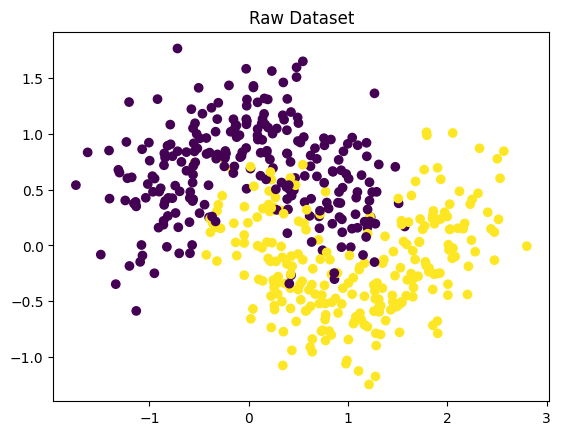

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_moons

from xgboost import XGBClassifier

X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Raw Dataset")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [7]:
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.89

Confusion Matrix:
 [[43  0]
 [11 46]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89        43
           1       1.00      0.81      0.89        57

    accuracy                           0.89       100
   macro avg       0.90      0.90      0.89       100
weighted avg       0.91      0.89      0.89       100



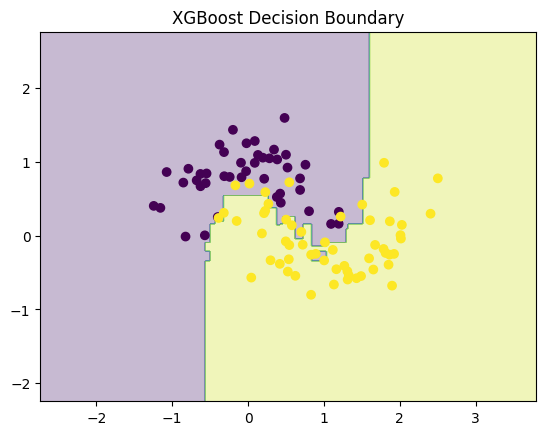

In [8]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = xgb.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("XGBoost Decision Boundary")
plt.show()